In [1]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm

import pickle

import matplotlib.pyplot as plt
import plotly.graph_objects as go

import matplotlib.ticker as ticker
import matplotlib.ticker as mtick
import matplotlib.colors as mcolors
import colorsys

from google.cloud import bigquery

import plotly.io as pio
pio.renderers.default = 'iframe'

from scipy.stats import fisher_exact
from scipy.stats import chi2_contingency
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

In [2]:
cset_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
cset_colors = ["#0B1F41","#003DA6","#B53A6D","#7AC4A5","#F17F4C","#15AFD0","#839DC5","#E5BF21"]

In [3]:
client = bigquery.Client()

In [4]:
query_text = """

WITH
all_papers AS (
  SELECT
    merged_id,
    COALESCE(t1.cluster_id, t2.cluster_id) AS cluster_id,
    COALESCE(resolved_funding_org = 'National Science Foundation', FALSE) AS is_nsf,
    COALESCE(resolved_funding_org = 'National Institutes of Health', FALSE) AS is_nih,
    resolved_funding_org IS NOT NULL AS is_nsfnih
  FROM staging_map_of_science.cluster_assignment AS t1
  LEFT JOIN IEEE_2026_paper_submission.nih_nsf_papers_resolved_funding AS t2 USING(merged_id)
),
within_cluster_refs AS (
  SELECT
    p1.cluster_id AS cluster_id,
    w.merged_id,
    p1.is_nsf AS is_nsf_merged_id,
    p1.is_nih AS is_nih_merged_id,
    p1.is_nsfnih AS is_nsfnih_merged_id,
    ref_id,
    p2.is_nsf AS is_nsf_ref_id,
    p2.is_nih AS is_nih_ref_id,
    p2.is_nsfnih AS is_nsfnih_ref_id,
    weight as weight,
    IF(w1.merged_id IS NOT NULL AND w1.ref_id IS NOT NULL, 1, 0) AS cit
  FROM staging_map_of_science.hybrid_weights AS w
  LEFT JOIN literature.references AS w1 USING(merged_id, ref_id)
  INNER JOIN all_papers AS p1 USING(merged_id)
  INNER JOIN all_papers AS p2 ON w.ref_id = p2.merged_id
  WHERE p1.cluster_id = p2.cluster_id
),
paper_counts AS (
  SELECT
    cluster_id,
    COUNT(DISTINCT merged_id) AS n_papers,
    COUNT(DISTINCT IF(is_nsf, merged_id, NULL)) AS n_nsf,
    COUNT(DISTINCT IF(is_nih, merged_id, NULL)) AS n_nih,
    COUNT(DISTINCT IF(is_nsfnih, merged_id, NULL)) AS n_nsfnih,
    COUNT(DISTINCT IF(is_nsf, NULL, merged_id)) AS n_nonnsf,
    COUNT(DISTINCT IF(is_nih, NULL, merged_id)) AS n_nonnih,
    COUNT(DISTINCT IF(is_nsfnih, NULL, merged_id)) AS n_nonnsfnih
  FROM all_papers 
  GROUP BY cluster_id
),
link_counts AS (
  SELECT
    cluster_id,
    COUNT(weight) AS n_edges,
    SUM(weight) AS weight,
    SUM(cit) AS links,

    COUNT(IF(is_nsf_merged_id OR is_nsf_ref_id, weight, NULL)) AS n_edges_nsf,
    COUNT(IF(is_nih_merged_id OR is_nih_ref_id, weight, NULL)) AS n_edges_nih,
    COUNT(IF(is_nsfnih_merged_id OR is_nsfnih_ref_id, weight, NULL)) AS n_edges_nsfnih,
    COUNT(IF(NOT(is_nsf_merged_id) OR NOT(is_nsf_ref_id), weight, NULL)) AS n_edges_nonnsf,
    COUNT(IF(NOT(is_nih_merged_id) OR NOT(is_nih_ref_id), weight, NULL)) AS n_edges_nonnih,
    COUNT(IF(NOT(is_nsfnih_merged_id) OR NOT(is_nsfnih_ref_id), weight, NULL)) AS n_edges_nonnsfnih,

    SUM(IF(is_nsf_merged_id OR is_nsf_ref_id, weight, NULL)) AS weight_nsf,
    SUM(IF(is_nih_merged_id OR is_nih_ref_id, weight, NULL)) AS weight_nih,
    SUM(IF(is_nsfnih_merged_id OR is_nsfnih_ref_id, weight, NULL)) AS weight_nsfnih,
    SUM(IF(NOT(is_nsf_merged_id) OR NOT(is_nsf_ref_id), weight, NULL)) AS weight_nonnsf,
    SUM(IF(NOT(is_nih_merged_id) OR NOT (is_nih_ref_id), weight, NULL)) AS weight_nonnih,
    SUM(IF(NOT(is_nsfnih_merged_id) OR NOT (is_nsfnih_ref_id), weight, NULL)) AS weight_nonnsfnih,

    SUM(IF(is_nsf_merged_id OR is_nsf_ref_id, cit, 0)) AS link_nsf,
    SUM(IF(is_nih_merged_id OR is_nih_ref_id, cit, 0)) AS link_nih,
    SUM(IF(is_nsfnih_merged_id OR is_nsfnih_ref_id, cit, 0)) AS link_nsfnih,
    SUM(IF(NOT(is_nsf_merged_id) OR NOT(is_nsf_ref_id), cit, 0)) AS link_nonnsf,
    SUM(IF(NOT(is_nih_merged_id) OR NOT (is_nih_ref_id), cit, 0)) AS link_nonnih,
    SUM(IF(NOT(is_nsfnih_merged_id) OR NOT (is_nsfnih_ref_id), cit, 0)) AS link_nonnsfnih,
  FROM within_cluster_refs
  GROUP BY cluster_id
)

SELECT
  cluster_id,
  # nodes
  n_nsf / n_papers AS frac_nodes_nsf,
  n_nih / n_papers AS frac_nodes_nih,
  n_nsfnih / n_papers AS frac_nodes_nsfnih,
  n_nonnsf / n_papers AS frac_nodes_nonnsf,
  n_nonnih / n_papers AS frac_nodes_nonnih,
  n_nonnsfnih / n_papers AS frac_nodes_nonnsfnih,
  # edges
  n_edges_nsf / n_edges AS frac_edges_nsf,
  n_edges_nih / n_edges AS frac_edges_nih,
  n_edges_nsfnih / n_edges AS frac_edges_nsfnih,
  n_edges_nonnsf / n_edges AS frac_edges_nonnsf,
  n_edges_nonnih / n_edges AS frac_edges_nonnih,
  n_edges_nonnsfnih / n_edges AS frac_edges_nonnsfnih,
  # weights
  weight_nsf / weight AS frac_weight_nsf,
  weight_nih / weight AS frac_weight_nih,
  weight_nsfnih / weight AS frac_weight_nsfnih,
  weight_nonnsf / weight AS frac_weight_nonnsf,
  weight_nonnih / weight AS frac_weight_nonnih,
  weight_nonnsfnih / weight AS frac_weight_nonnsfnih,
  # links
  link_nsf / links AS frac_link_nsf,
  link_nih / links AS frac_link_nih,
  link_nsfnih / links AS frac_link_nsfnih,
  link_nonnsf / links AS frac_link_nonnsf,
  link_nonnih / links AS frac_link_nonnih,
  link_nonnsfnih / links AS frac_link_nonnsfnih,
  n_papers,
  n_edges,
  weight
FROM paper_counts
FULL JOIN link_counts USING(cluster_id)

"""

query = client.query(query_text)
network_stats = pd.DataFrame([{k:v for k,v in row.items()} for row in query])

In [5]:
# Adding in expected fractions, assuming fully connected network of size n_cluster_papers with nodes of interest n_nsf, n_nih, or n_nsfnih

N = network_stats['n_papers']

n = N * network_stats['frac_nodes_nsf']
network_stats['frac_edges_nsf_fully_connected'] = (2*n*N - n**2 - n)/(N*(N-1))

n = N * network_stats['frac_nodes_nonnsf']
network_stats['frac_edges_nonnsf_fully_connected'] = (2*n*N - n**2 - n)/(N*(N-1))

n = N * network_stats['frac_nodes_nih']
network_stats['frac_edges_nih_fully_connected'] = (2*n*N - n**2 - n)/(N*(N-1))

n = N * network_stats['frac_nodes_nonnih']
network_stats['frac_edges_nonnih_fully_connected'] = (2*n*N - n**2 - n)/(N*(N-1))

n = N * network_stats['frac_nodes_nsfnih']
network_stats['frac_edges_nsfnih_fully_connected'] = (2*n*N - n**2 - n)/(N*(N-1))

n = N * network_stats['frac_nodes_nonnsfnih']
network_stats['frac_edges_nonnsfnih_fully_connected'] = (2*n*N - n**2 - n)/(N*(N-1))

In [6]:
# finding the "effective" proportion of 
y_nsf = network_stats['frac_edges_nsf']
network_stats['frac_edges_ideal_nodes_nsf'] = 1 - np.sqrt(1-y_nsf)

y_nih = network_stats['frac_edges_nih']
network_stats['frac_edges_ideal_nodes_nih'] = 1 - np.sqrt(1-y_nih)

y_nsfnih = network_stats['frac_edges_nsfnih']
network_stats['frac_edges_ideal_nodes_nsfnih'] = 1 - np.sqrt(1-y_nsfnih)

y_nonnsfnih = network_stats['frac_edges_nonnsfnih']
network_stats['frac_edges_ideal_nodes_nonnsfnih'] = 1 - np.sqrt(1-y_nonnsfnih)

In [7]:
x_nsfnih_linfit = network_stats[network_stats['frac_nodes_nsfnih'] > 0]['frac_nodes_nsfnih']
y_nsfnih_linfit = network_stats[network_stats['frac_nodes_nsfnih'] > 0]['frac_edges_ideal_nodes_nsfnih']
linmodel_nsfnih = sm.OLS(y_nsfnih_linfit, x_nsfnih_linfit).fit()
print(linmodel_nsfnih.summary())

                                      OLS Regression Results                                      
Dep. Variable:     frac_edges_ideal_nodes_nsfnih   R-squared (uncentered):                   0.967
Model:                                       OLS   Adj. R-squared (uncentered):              0.967
Method:                            Least Squares   F-statistic:                          2.066e+06
Date:                           Wed, 12 Aug 2026   Prob (F-statistic):                        0.00
Time:                                   14:33:05   Log-Likelihood:                      1.9706e+05
No. Observations:                          71527   AIC:                                 -3.941e+05
Df Residuals:                              71526   BIC:                                 -3.941e+05
Df Model:                                      1                                                  
Covariance Type:                       nonrobust                                                  
          

In [8]:
x_nsf_linfit = network_stats[network_stats['frac_nodes_nsf'] > 0]['frac_nodes_nsf']
y_nsf_linfit = network_stats[network_stats['frac_nodes_nsf'] > 0]['frac_edges_ideal_nodes_nsf']
linmodel_nsf = sm.OLS(y_nsf_linfit, x_nsf_linfit).fit()
print(linmodel_nsf.summary())

                                     OLS Regression Results                                    
Dep. Variable:     frac_edges_ideal_nodes_nsf   R-squared (uncentered):                   0.919
Model:                                    OLS   Adj. R-squared (uncentered):              0.919
Method:                         Least Squares   F-statistic:                          5.424e+05
Date:                        Wed, 12 Aug 2026   Prob (F-statistic):                        0.00
Time:                                14:33:05   Log-Likelihood:                      1.8657e+05
No. Observations:                       47490   AIC:                                 -3.731e+05
Df Residuals:                           47489   BIC:                                 -3.731e+05
Df Model:                                   1                                                  
Covariance Type:                    nonrobust                                                  
                     coef    std err    

In [9]:
x_nih_linfit = network_stats[network_stats['frac_nodes_nih'] > 0]['frac_nodes_nih']
y_nih_linfit = network_stats[network_stats['frac_nodes_nih'] > 0]['frac_edges_ideal_nodes_nih']
linmodel_nih = sm.OLS(y_nih_linfit, x_nih_linfit).fit()
print(linmodel_nih.summary())

                                     OLS Regression Results                                    
Dep. Variable:     frac_edges_ideal_nodes_nih   R-squared (uncentered):                   0.967
Model:                                    OLS   Adj. R-squared (uncentered):              0.967
Method:                         Least Squares   F-statistic:                          1.471e+06
Date:                        Wed, 12 Aug 2026   Prob (F-statistic):                        0.00
Time:                                14:33:05   Log-Likelihood:                      1.3052e+05
No. Observations:                       49972   AIC:                                 -2.610e+05
Df Residuals:                           49971   BIC:                                 -2.610e+05
Df Model:                                   1                                                  
Covariance Type:                    nonrobust                                                  
                     coef    std err    

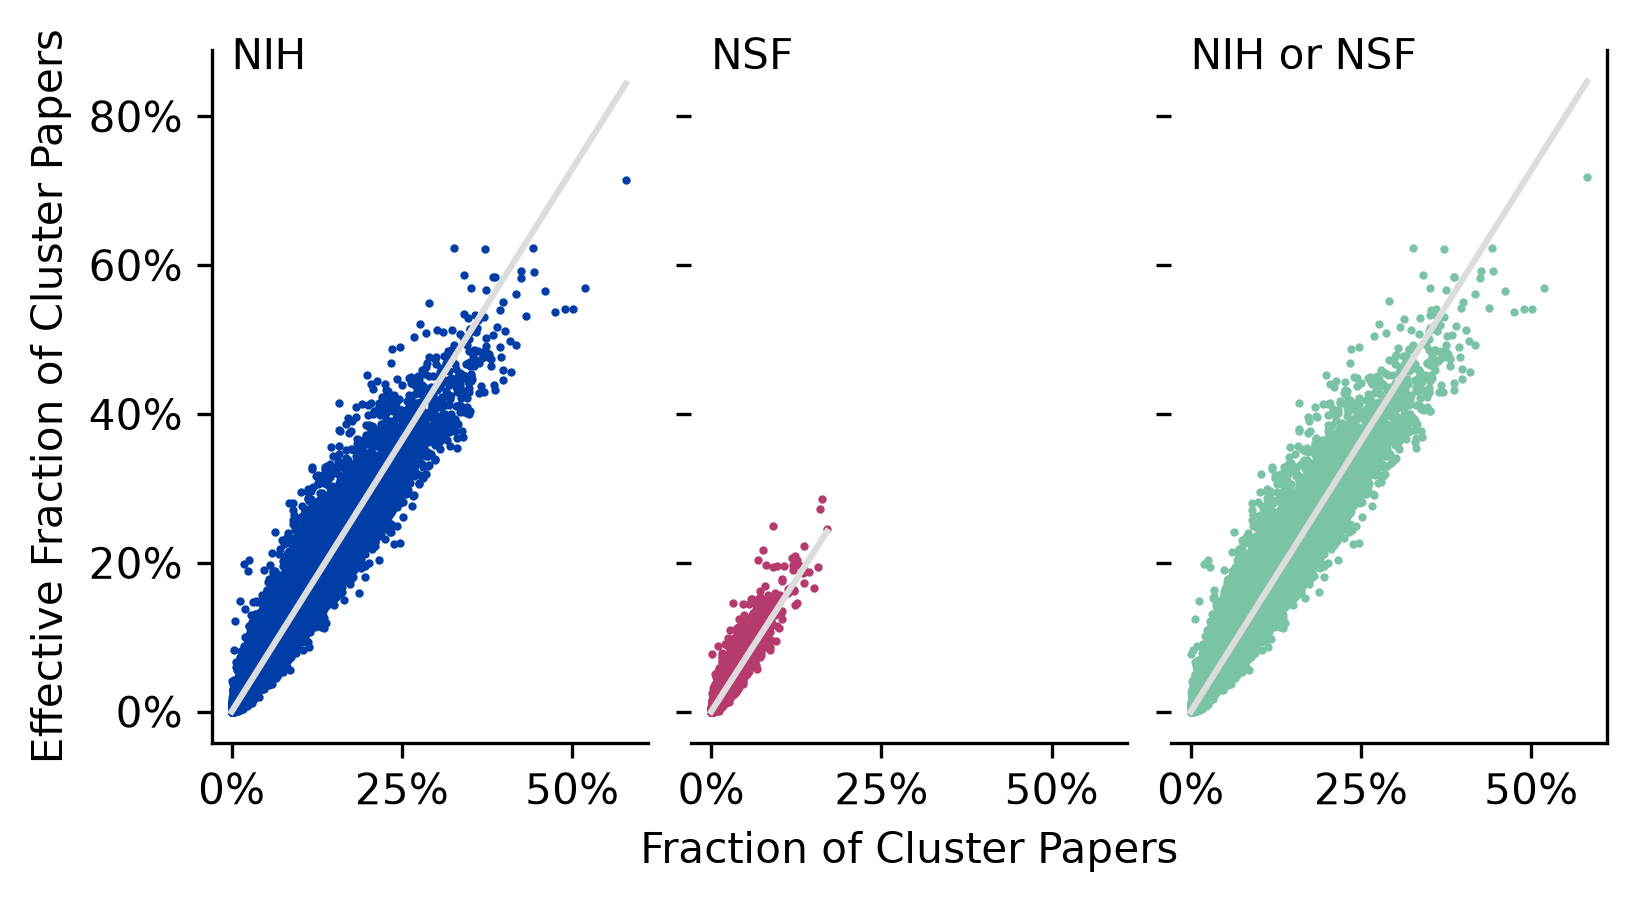

In [61]:
size = 1

fig, axs = plt.subplots(figsize=(6,3), ncols=3, sharey = True, sharex = True, dpi=300)
plt.subplots_adjust(wspace=0.1)

axs[1].scatter(x_nsf_linfit, y_nsf_linfit, c=cset_colors[2], s=size,
            label='NSF Papers')
axs[0].scatter(x_nih_linfit, y_nih_linfit, c=cset_colors[1], s=size,
            label='NIH Papers')
axs[2].scatter(x_nsfnih_linfit, y_nsfnih_linfit, c=cset_colors[3], s=size,
            label='NSF or NIH')

axs[1].plot([min(x_nsf_linfit), max(x_nsf_linfit)], 
         [linmodel_nsf.params.values[0]*min(x_nsf_linfit), 
          linmodel_nsf.params.values[0]*max(x_nsf_linfit)],
         c='gainsboro', label='Regression')
axs[0].plot([min(x_nih_linfit), max(x_nih_linfit)], 
         [linmodel_nih.params.values[0]*min(x_nih_linfit), 
          linmodel_nih.params.values[0]*max(x_nih_linfit)],
         c='gainsboro', label='Regression')
axs[2].plot([min(x_nsfnih_linfit), max(x_nsfnih_linfit)], 
         [linmodel_nsfnih.params.values[0]*min(x_nsfnih_linfit), 
          linmodel_nsfnih.params.values[0]*max(x_nsfnih_linfit)],
         c='gainsboro', label='Regression')

axs[1].set_xlabel('Fraction of Cluster Papers')
axs[0].set_ylabel('Effective Fraction of Cluster Papers')

axs[0].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
axs[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

axs[0].annotate('NIH', xy=(0.0,0.85), ha='left', va='bottom')
axs[1].annotate('NSF', xy=(0.0,0.85), ha='left', va='bottom')
axs[2].annotate('NIH or NSF', xy=(0.0,0.85), ha='left', va='bottom')

#axs[0].legend()
#axs[1].legend()
#axs[2].legend()

axs[0].spines[['right','top']].set_visible(False)
axs[1].spines[['right','left','top']].set_visible(False)
axs[2].spines[['left','top']].set_visible(False)

#plt.suptitle('Effective Network Size of Funded Papers', weight='bold')

plt.savefig('../figures/effective_network_sizes.png', transparent=True, bbox_inches='tight')

plt.show()

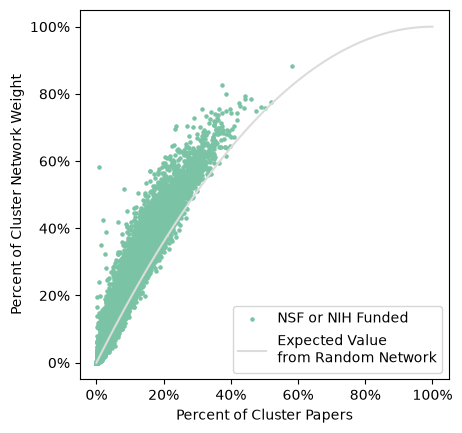

In [60]:
size = 5

# Funded papers

x1 = network_stats['frac_nodes_nsfnih']
y1 = network_stats['frac_weight_nsfnih']
plt.scatter(x1, y1, c=cset_colors[3], s = size, label='NSF or NIH Funded')

x2 = network_stats['frac_nodes_nih']
y2 = network_stats['frac_weight_nih']
#plt.scatter(x2, y2, c=cset_colors[1], s = size, label='NIH')

x3 = network_stats['frac_nodes_nsf']
y3 = network_stats['frac_weight_nsf']
#plt.scatter(x3, y3, c=cset_colors[2], s = size, label='NSF')

# Non Funded papers

x11 = network_stats['frac_nodes_nonnsfnih']
y11 = network_stats['frac_weight_nonnsfnih']
#plt.scatter(x11, y11, c=cset_colors[4], s = size, label='Non NSF/NIH')

x22 = network_stats['frac_nodes_nonnih']
y22 = network_stats['frac_weight_nonnih']
#plt.scatter(x22, y22, c=cset_colors[4], s = size, label='Non NIH')

x33 = network_stats['frac_nodes_nonnsf']
y33 = network_stats['frac_weight_nonnsf']
#plt.scatter(x33, y33, c=cset_colors[5], s = size, label='Non NSF')

x_pred = np.linspace(0,1,100)
y_pred = x_pred * (2-x_pred)

plt.plot(x_pred, y_pred, c='gainsboro', label='Expected Value\nfrom Random Network')
plt.xlabel('Percent of Cluster Papers')
plt.ylabel('Percent of Cluster Network Weight')

plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

#plt.title('Contribution of Funded Papers\nto Cluster Research Networks', weight='bold', loc='left')

plt.legend()
plt.gca().set_aspect('equal')

plt.savefig('../figures/contribution_funded_papers_research_cluster_network.png', transparent=True, bbox_inches='tight')
plt.savefig('../figures/contribution_funded_papers_research_cluster_network.pdf', bbox_inches='tight')

plt.show()